In [1]:
import numpy as np
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from pytorch_lightning.callbacks import ModelCheckpoint
from torch.utils.data import DataLoader
from torchvision import models
import pytorch_lightning as pl
from pytorch_lightning import loggers as pl_loggers
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks import LearningRateMonitor
from typing import Any, Dict, List, Tuple

(20, 2, 60, 256, 256)


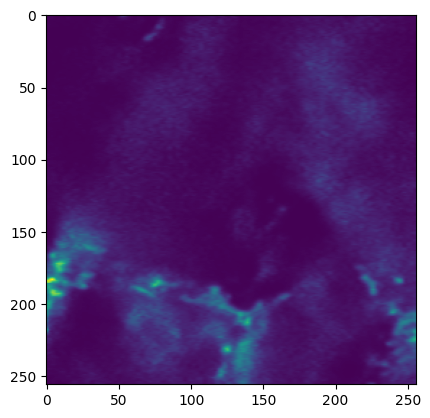

In [2]:
image = np.load('../Data/000000.npy')
print(image.shape)
plt.imshow(image[0, 1, 1, :])

In [3]:
import torch
import torch.nn as nn

class MitoSpace3DEncoder(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=[1, 4, 16, 4, 1]):
        super(MitoSpace3DEncoder, self).__init__()

        # Define the entire encoder as a single sequential block
        self.encoder = nn.Sequential(
            # Layer 1: Conv, BatchNorm, ReLU (with bias)
            nn.Conv3d(in_channels=input_dim, out_channels=hidden_dim[0], kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=True),
            nn.BatchNorm3d(hidden_dim[0]),
            nn.ReLU(inplace=True),

            # Layer 2: Conv, BatchNorm, ReLU (with bias)
            nn.Conv3d(in_channels=hidden_dim[0], out_channels=hidden_dim[1], kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=True),
            nn.BatchNorm3d(hidden_dim[1]),
            nn.ReLU(inplace=True),

            # Layer 3: Conv, BatchNorm, ReLU (with bias, downsampling)
            nn.Conv3d(in_channels=hidden_dim[1], out_channels=hidden_dim[2], kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=True),
            nn.BatchNorm3d(hidden_dim[2]),
            nn.ReLU(inplace=True),

            # Layer 4: Conv, BatchNorm, ReLU (with bias, downsampling)
            nn.Conv3d(in_channels=hidden_dim[2], out_channels=hidden_dim[3], kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=True),
            nn.BatchNorm3d(hidden_dim[3]),
            nn.ReLU(inplace=True),

            # Layer 5: Conv, BatchNorm, ReLU (with bias)
            nn.Conv3d(in_channels=hidden_dim[3], out_channels=hidden_dim[4], kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=True),
            nn.BatchNorm3d(hidden_dim[4]),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Step 1: Reshape from [20, 2, 60, 256, 256] to [40, 60, 256, 256]
        batch_size, timesteps, channels, depth, height, width = x.shape
        x = x.view(batch_size * timesteps * channels, depth, height, width).unsqueeze(1)  # Merge batch and channel dimensions

        # Step 2: Apply the encoder to downsample
        x = self.encoder(x)

        # Step 3: Reshape back to [20, 2, 15, 64, 64]
        _, _, new_stacks, new_height, new_width = x.shape
        x = x.view(batch_size, timesteps, channels, new_stacks, new_height, new_width)  # Split batch and channel dimensions

        return x

# Example usage:
input_data = torch.randn(2, 5, 2, 60, 256, 256)

# Using default input_dim and hidden_dim
encoder = MitoSpace3DEncoder()
output = encoder(input_data)
print('Output shape:', output.shape)


Output shape: torch.Size([2, 5, 2, 15, 64, 64])


In [4]:
import torch
import torch.nn as nn

class MitoSpace3DDecoder(nn.Module):
    def __init__(self, output_dim=1, hidden_dim=[1, 4, 16, 4, 1]):
        super(MitoSpace3DDecoder, self).__init__()

        # Define the entire decoder as a single sequential block
        self.decoder = nn.Sequential(
            # Layer 1: Transpose Conv, BatchNorm, ReLU (with bias)
            nn.ConvTranspose3d(in_channels=hidden_dim[4], out_channels=hidden_dim[3], kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=True),
            nn.BatchNorm3d(hidden_dim[3]),
            nn.ReLU(inplace=True),

            # Layer 2: Transpose Conv, BatchNorm, ReLU (upsampling, with bias)
            nn.ConvTranspose3d(in_channels=hidden_dim[3], out_channels=hidden_dim[2], kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), output_padding=(1, 1, 1), bias=True),
            nn.BatchNorm3d(hidden_dim[2]),
            nn.ReLU(inplace=True),

            # Layer 3: Transpose Conv, BatchNorm, ReLU (upsampling, with bias)
            nn.ConvTranspose3d(in_channels=hidden_dim[2], out_channels=hidden_dim[1], kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), output_padding=(1, 1, 1), bias=True),
            nn.BatchNorm3d(hidden_dim[1]),
            nn.ReLU(inplace=True),

            # Layer 4: Transpose Conv, BatchNorm, ReLU (with bias)
            nn.ConvTranspose3d(in_channels=hidden_dim[1], out_channels=hidden_dim[0], kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=True),
            nn.BatchNorm3d(hidden_dim[0]),
            nn.ReLU(inplace=True),

            # Final output layer (with bias)
            nn.ConvTranspose3d(in_channels=hidden_dim[0], out_channels=output_dim, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=True)
        )

    def forward(self, x):
        # Apply the decoder to upsample
        batch_size, timesteps, channels, depth, height, width = x.shape
        x = x.view(batch_size * timesteps * channels, depth, height, width).unsqueeze(1)  # Merge batch and channel dimensions

        # Forward pass through the decoder
        x = self.decoder(x)

        # Step 3: Reshape back to [batch_size, timesteps, channels, depth, height, width]
        _, _, new_stacks, new_height, new_width = x.shape
        x = x.view(batch_size, timesteps, channels, new_stacks, new_height, new_width)  # Split batch and channel dimensions
        print(f"Final output shape: {x.shape}")

        return x

# Example usage:
input_data = torch.randn(2, 5, 2, 15, 64, 64)  # Example shape after encoder

# Using default output_dim and hidden_dim
decoder = MitoSpace3DDecoder()
output = decoder(input_data)
print('Output shape:', output.shape)


Final output shape: torch.Size([2, 5, 2, 60, 256, 256])
Output shape: torch.Size([2, 5, 2, 60, 256, 256])


In [5]:
class MitoSpace3DAutoencoder(nn.Module):
    def __init__(self, input_dim=1, output_dim=1, hidden_dim=[1, 4, 16, 4, 1]):
        super(MitoSpace3DAutoencoder, self).__init__()
        self.encoder = MitoSpace3DEncoder(input_dim=input_dim, hidden_dim=hidden_dim)
        self.decoder = MitoSpace3DDecoder(output_dim=output_dim, hidden_dim=hidden_dim)

    def forward(self, x):
        # Pass through the encoder
        x = self.encoder(x)
        # Pass through the decoder
        return self.decoder(x)

# Example usage:
input_data = torch.randn(3, 5, 2, 60, 256, 256)

# Using default input_dim and hidden_dim
autoencoder = MitoSpace3DAutoencoder()
output = autoencoder(input_data)
print('Output shape', output.shape)

Final output shape: torch.Size([3, 5, 2, 60, 256, 256])
Output shape torch.Size([3, 5, 2, 60, 256, 256])


In [6]:
class Autoencoder(pl.LightningModule):
    def __init__(
        self,
        model,
    ):
        super().__init__()
        # Saving hyperparameters of autoencoder
        self.model = model
        self.intermediate_outputs = []
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=100)
        self.data_bank = {"Train": [], "Val": []}

        print(f"###################### Using MSE Loss For Training ##################")

        self.criterion = nn.MSELoss(reduction = 'mean')

    def forward(self, x):
        """The forward function takes in an image and returns the reconstructed image."""
        return self.model(x)

    def _get_reconstruction_loss(self, batch):
        """Given a batch of images, this function returns the reconstruction loss (MSE in our case)."""
        x, _ = batch  # We do not need the labels
        x_hat = self.forward(x)
        loss = self.criterion(x, x_hat)
        return loss

    def configure_optimizers(self):
        optimizer = self.optimizer
        scheduler = self.scheduler

        return {"optimizer": optimizer, "lr_scheduler": scheduler, "monitor": "val_loss"}

    def training_step(self, batch, batch_idx):
        loss = self._get_reconstruction_loss(batch)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self._get_reconstruction_loss(batch)
        self.log("val_loss", loss)

    def test_step(self, batch, batch_idx):
        loss = self._get_reconstruction_loss(batch)
        self.log("test_loss", loss)

In [ ]:
def train_model():
    # Create a PyTorch Lightning trainer with the generation callback
    trainer = pl.Trainer(
        default_root_dir=os.path.join(CHECKPOINT_PATH, "cifar10_%i" % latent_dim),
        accelerator="auto",
        devices=1,
        max_epochs=500,
        callbacks=[
            ModelCheckpoint(save_weights_only=True),
            LearningRateMonitor("epoch"),
        ],
    )
    trainer.logger._log_graph = True  # If True, we plot the computation graph in tensorboard
    trainer.logger._default_hp_metric = None  # Optional logging argument that we don't need

    # Check whether pretrained model exists. If yes, load it and skip training
    model = Autoencoder(base_channel_size=32, latent_dim=latent_dim)
    trainer.fit(model, train_loader, val_loader)
    # Test best model on validation and test set
    val_result = trainer.test(model, dataloaders=val_loader, verbose=False)
    test_result = trainer.test(model, dataloaders=test_loader, verbose=False)
    result = {"test": test_result, "val": val_result}
    return model, result